# Prerequisite — Neural Networks Fundamentals

Understanding the basics of how neural networks learn before starting LLMs.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## Training Data (Examples given to the model)

In [2]:
training_data = [
    ([1., 2.], 3.),
    ([3., 4.], 7.),
    ([5., 1.], 6.),
    ([2., 8.], 10.),
    ([4., 5.], 9.)
]

print("Training Examples:")
for x, y in training_data:
    print(f"  Input: {x} → Target: {y}")

print("\nNote: [2, 3] → 5 is NOT in training data.")

Training Examples:
  Input: [1.0, 2.0] → Target: 3.0
  Input: [3.0, 4.0] → Target: 7.0
  Input: [5.0, 1.0] → Target: 6.0
  Input: [2.0, 8.0] → Target: 10.0
  Input: [4.0, 5.0] → Target: 9.0

Note: [2, 3] → 5 is NOT in training data.


## Training the Neural Network

In [3]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
    def forward(self, x):
        return self.linear(x)

model = SimpleNN()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

losses = []

for epoch in range(50):
    total_loss = 0
    for x_data, y_true in training_data:
        x = torch.tensor([x_data])
        target = torch.tensor([[y_true]])

        prediction = model(x)
        loss = loss_fn(prediction, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss / len(training_data))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d} | Loss: {losses[-1]:.6f}")

Epoch  0 | Loss: 14.033512
Epoch 10 | Loss: 0.012439
Epoch 20 | Loss: 0.010339
Epoch 30 | Loss: 0.008591
Epoch 40 | Loss: 0.007138


## Test on Unseen Example

In [4]:
test_input = torch.tensor([[2., 3.]])
prediction = model(test_input)

print("\n=== TEST EXAMPLE (Never seen during training) ===")
print(f"Input : [2.0, 3.0]")
print(f"Target: 5.0")
print(f"Model Predicted: {prediction.item():.4f}")


=== TEST EXAMPLE (Never seen during training) ===
Input : [2.0, 3.0]
Target: 5.0
Model Predicted: 5.1098


## Loss Curve

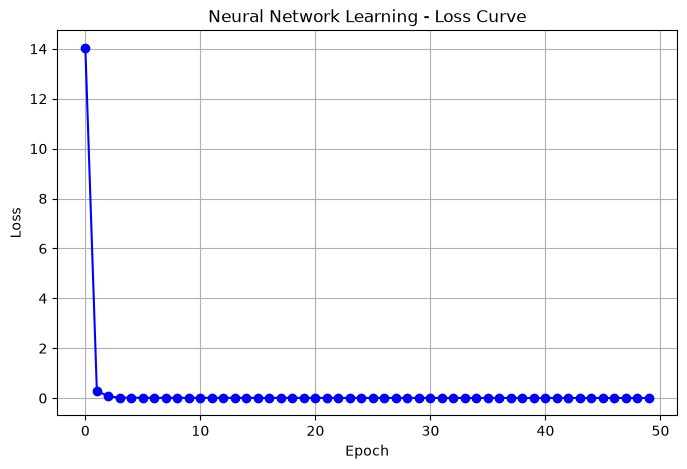

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o', color='blue')
plt.title("Neural Network Learning - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()